In [1]:
!pip install ultralytics -q
!pip install git+https://github.com/facebookresearch/segment-anything.git -q

# Descarga del modelo SAM
!wget https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth -O /content/sam_vit_h_4b8939.pth

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 25.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 29.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 16.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 85.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
--2025-06-28 23:23:30--  https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO
from segment_anything import SamPredictor, sam_model_registry
import os
from uuid import uuid4
import pandas as pd
import json
from collections import defaultdict
from google.colab import files

# Directorios
os.makedirs('images', exist_ok=True)
os.makedirs('outputs/recortes', exist_ok=True)
os.makedirs('outputs/segmentaciones', exist_ok=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
!ls /content/

images	outputs  sample_data  sam_vit_h_4b8939.pth


100%|██████████| 6.25M/6.25M [00:00<00:00, 101MB/s]



image 1/1 /content/images/prueba2Animales.png: 384x640 1 cat, 1 dog, 292.8ms
Speed: 14.1ms preprocess, 292.8ms inference, 32.8ms postprocess per image at shape (1, 3, 384, 640)


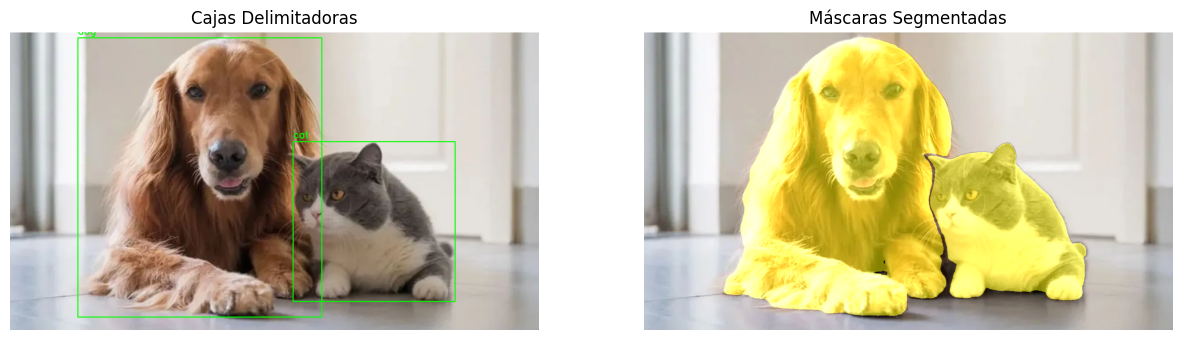

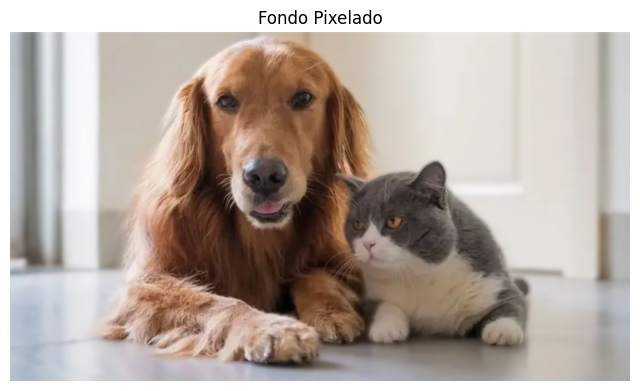

Conteo por clase:
- dog: 1 objeto(s)
- cat: 1 objeto(s)


,objeto_id,clase,x1,y1,x2,y2,area_pixeles,area_%,perimetro,centroide_x,centroide_y
0,0,dog,191,16,879,804,371995,29.65,2672.84,571,437
1,1,cat,798,309,1255,760,134337,10.71,1676.96,1012,554


In [4]:
# Función 1: Detección de objetos con YOLO
def detectar_objetos_yolo(imagen_path):
    """
    Detecta objetos en una imagen usando YOLOv8.
    Retorna las coordenadas de las cajas delimitadoras, las clases y la imagen cargada.
    """
    model = YOLO('yolov8n.pt')
    results = model(imagen_path)

    boxes = []
    classes = []
    imagen = results[0].orig_img if results else cv2.imread(imagen_path)
    if not imagen is None:
        for result in results:
            for box in result.boxes:
                x_min, y_min, x_max, y_max = box.xyxy[0].cpu().numpy().astype(int)
                cls = result.names[int(box.cls)]
                if cls in ['dog', 'cat'] and float(box.conf[0]) > 0.5:
                    boxes.append([x_min, y_min, x_max, y_max])
                    classes.append(cls)
    else:
        raise ValueError("No se pudo cargar la imagen.")
    return boxes, classes, imagen

# Función 2: Segmentación con SAM
def segmentar_con_sam(imagen, boxes):
    """
    Segmenta objetos usando SAM con las cajas de YOLO como prompts.
    Retorna una lista de máscaras.
    """
    sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
    predictor = SamPredictor(sam)
    predictor.set_image(imagen)

    masks = []
    for box in boxes:
        input_box = np.array(box)
        mask, _, _ = predictor.predict(
            box=input_box[None, :],
            multimask_output=False
        )
        masks.append(mask[0].astype(np.uint8))
    return masks

# Función 3: Visualización de resultados
def visualizar_deteccion_segmentacion(imagen, boxes, masks, classes):
    """
    Visualiza la imagen original con cajas y máscaras, y guarda recortes.
    """
    img_with_boxes = imagen.copy()
    img_with_masks = imagen.copy()

    for i, (box, mask, cls) in enumerate(zip(boxes, masks, classes)):
        x_min, y_min, x_max, y_max = box
        cv2.rectangle(img_with_boxes, (x_min, y_min), (x_max, y_max), (0, 255, 0), 2)
        cv2.putText(img_with_boxes, cls, (x_min, y_min - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0, 255, 0), 2)

        mask_color = np.zeros_like(imagen)
        mask_color[mask > 0] = [0, 255, 255]  # Color cian
        img_with_masks = cv2.addWeighted(img_with_masks, 1, mask_color, 0.5, 0)

        # Recorte con fondo blanco
        mask_3ch = np.stack([mask] * 3, axis=-1)
        cropped = np.where(mask_3ch, imagen, 255)
        cropped = cropped[y_min:y_max, x_min:x_max]
        cv2.imwrite(f'outputs/recortes/{cls}_{str(uuid4())[:8]}.png', cropped)

        # Guardar máscara individual
        cv2.imwrite(f'outputs/segmentaciones/mask_{cls}_{str(uuid4())[:8]}.png', mask * 255)

    cv2.imwrite('outputs/resultados.png', cv2.cvtColor(img_with_boxes, cv2.COLOR_RGB2BGR))

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.title("Cajas Delimitadoras")
    plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Máscaras Segmentadas")
    plt.imshow(cv2.cvtColor(img_with_masks, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()


# Función 4: Análisis creativo (pixelado del fondo)
def analizar_segmentaciones(imagen, masks, boxes, classes):
    img_pixelated = cv2.GaussianBlur(imagen, (21, 21), 0)
    combined_mask = np.zeros_like(imagen[:, :, 0], dtype=bool)

    datos = []
    conteo_clases = defaultdict(int)
    h, w = imagen.shape[:2]
    total_area = h * w

    for i, (mask, box, cls) in enumerate(zip(masks, boxes, classes)):
        combined_mask |= (mask > 0)
        area = np.sum(mask)
        x_min, y_min, x_max, y_max = box
        conteo_clases[cls] += 1
        porcentaje = round((area / total_area) * 100, 2)

        # Calcular perímetro y centroide
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        perimeter = cv2.arcLength(contours[0], True) if contours else 0
        M = cv2.moments(mask) if contours else {'m10': 0, 'm01': 0, 'm00': 0}
        centroid_x = int(M['m10'] / M['m00']) if M['m00'] else x_min + (x_max - x_min) // 2
        centroid_y = int(M['m01'] / M['m00']) if M['m00'] else y_min + (y_max - y_min) // 2

        datos.append({
            "objeto_id": int(i),  # Convertir a int nativo
            "clase": cls,
            "x1": int(x_min), "y1": int(y_min), "x2": int(x_max), "y2": int(y_max),  # Convertir a int nativo
            "area_pixeles": int(area),  # Convertir a int nativo
            "area_%": porcentaje,
            "perimetro": round(perimeter, 2),
            "centroide_x": int(centroid_x),  # Convertir a int nativo
            "centroide_y": int(centroid_y)   # Convertir a int nativo
        })

    result = np.where(np.stack([combined_mask] * 3, axis=-1), imagen, img_pixelated)
    cv2.imwrite('outputs/pixelado_fondo.png', cv2.cvtColor(result, cv2.COLOR_RGB2BGR))

    plt.figure(figsize=(8, 8))
    plt.title("Fondo Pixelado")
    plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

    # Guardar datos en JSON
    with open('outputs/analisis.json', 'w') as f:
        json.dump(datos, f, indent=4)

    return pd.DataFrame(datos), conteo_clases

# Ejecución del pipeline y descarga automática
def main(image_path='/content/images/prueba2Animales.png'):
    try:
        # Paso 1: Detección con YOLO
        boxes, classes, imagen = detectar_objetos_yolo(image_path)
        if not boxes:
            print("No se detectaron perros ni gatos.")
            return

        # Paso 2: Segmentación con SAM
        masks = segmentar_con_sam(imagen, boxes)

        # Paso 3: Visualización
        visualizar_deteccion_segmentacion(imagen, boxes, masks, classes)

        # Paso 4: Análisis
        datos_objetos, conteo_clases = analizar_segmentaciones(imagen, masks, boxes, classes)

        # Mostrar conteo por clase
        print("Conteo por clase:")
        for clase, count in conteo_clases.items():
            print(f"- {clase}: {count} objeto(s)")

        # Mostrar tabla de datos
        display(datos_objetos)

    except Exception as e:
        print(f"Error: {str(e)}")

if __name__ == "__main__":
    main()

In [5]:
!zip -r outputs.zip outputs
files.download('outputs.zip')

  adding: outputs/ (stored 0%)
  adding: outputs/pixelado_fondo.png (deflated 7%)
  adding: outputs/recortes/ (stored 0%)
  adding: outputs/recortes/cat_0fec5882.png (deflated 5%)
  adding: outputs/recortes/dog_d8f5e83c.png (deflated 4%)
  adding: outputs/analisis.json (deflated 65%)
  adding: outputs/segmentaciones/ (stored 0%)
  adding: outputs/segmentaciones/mask_dog_efe213fc.png (deflated 24%)
  adding: outputs/segmentaciones/mask_cat_5bee806f.png (deflated 40%)
  adding: outputs/resultados.png (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>